# What is Linear Regression?

## What is regression?

In machine learning, we have two broad types of problems:

- **Classification** → predict a *category*: "Is this email spam or not?"
- **Regression** → predict a *number*: "What will this house sell for?"

**Linear regression** is the simplest and most foundational regression algorithm.
It is the first algorithm every ML engineer learns — and it still gets used in production at major companies.

Problem:

We want to predict a continuous value.

Examples:
- House price prediction
- Salary prediction
- Sales forecasting
- Ad spend → Revenue estimation
- Temperature prediction

Linear regression assumes:

y = ${\beta_0 + \beta_1 x + \epsilon}$

Where:
- ${\beta_0}$ → Intercept
- ${\beta_1}$ → Slope
-	${\epsilon}$ → Error (noise)


Linear Regression is used in:
- 🏠 Real estate pricing
- 📈 Revenue forecasting
- 💰 Finance (risk modeling)
- 📊 Marketing ROI analysis
- 🧠 Baseline model in ML pipelines

## What will we learn?

| Section | Topic |
|---|---|
| 1 | The core idea — fitting a line |
| 2 | The equation — what the model actually computes |
| 3 | The loss function — how we measure "wrong" |
| 4 | Ordinary Least Squares — solving it with math |
| 5 | Gradient descent — solving it iteratively |
| 6 | Multiple features — more than one input |
| 7 | Assumptions — when does linear regression work? |
| 8 | Evaluating the model — R², RMSE, residuals |
| 9 | sklearn in 5 lines |
| 10 | Real example — Boston-style housing data |


<br/>

> Think of linear regression as the "Hello World" of predictive modeling.
> Every more complex algorithm (neural networks, XGBoost, transformers) is solving the same problem — just with more sophistication."""


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import warnings

warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## 1. The Core Idea — Fitting a Line

Imagine We have data on house sizes and their prices.
We notice: **bigger houses tend to cost more.**

Linear regression finds the **best straight line** through that data — one we can use to predict prices for houses we haven't seen yet.

```
price = m × size + b
         ↑           ↑
      slope       intercept
   (price per sqft)  (base price)
```

The "best" line is the one that **minimizes the total prediction error** across all our data points.

That's it. That's linear regression at its core.

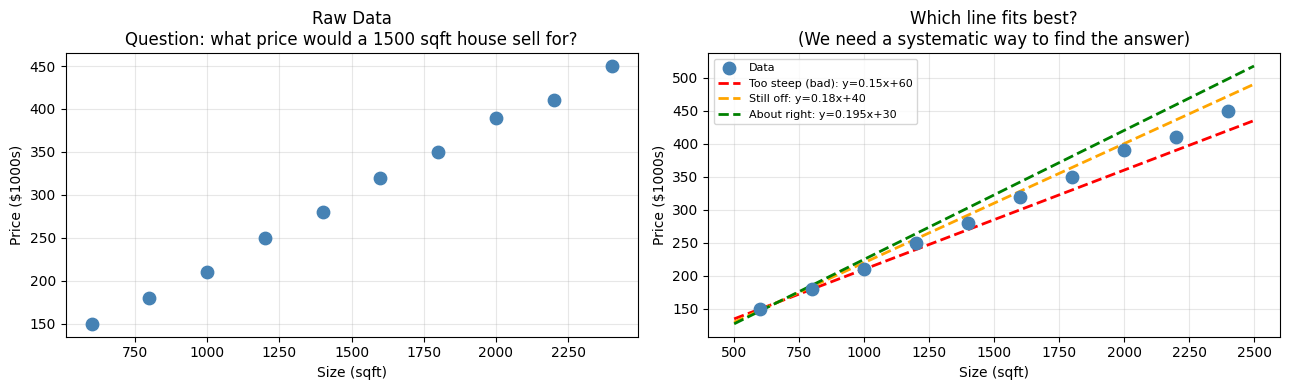

In [2]:
# Simple example: house size vs price
sizes  = np.array([600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400])
# in $1000s
prices = np.array([150, 180,  210,  250,  280,  320,  350,  390,  410,  450])

# Plot raw data
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(sizes, prices, color='steelblue', s=80, zorder=5)
axes[0].set_title('Raw Data\nQuestion: what price would a 1500 sqft house sell for?')
axes[0].set_xlabel('Size (sqft)')
axes[0].set_ylabel('Price ($1000s)')

# Try a few lines manually to build intuition
x_line = np.linspace(500, 2500, 100)
lines = [
    (0.15, 60,  'red',       'Too steep (bad)'),
    (0.18, 40,  'orange',    'Still off'),
    (0.195, 30, 'green',     'About right'),
]
axes[1].scatter(sizes, prices, color='steelblue', s=80, zorder=5, label='Data')
for m, b, color, label in lines:
    axes[1].plot(x_line, m*x_line + b, color=color, lw=2, linestyle='--', label=f'{label}: y={m}x+{b}')
axes[1].set_title('Which line fits best?\n(We need a systematic way to find the answer)')
axes[1].set_xlabel('Size (sqft)')
axes[1].set_ylabel('Price ($1000s)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 2. The Equation — What the Model Computes

### Simple Linear Regression (one feature)
$${\hat{y} = w \cdot x + b}$$

- ${\hat{y}}$ = prediction (what the model outputs)
- $x$ = input feature (house size)
- $w$ = **weight** (slope) — how much price increases per unit of size
- $b$ = **bias** (intercept) — base value when x=0

### Multiple Linear Regression (many features)
$$\hat{y} = w_1 x_1 + w_2 x_2 + ... + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$

In matrix form for a whole dataset:
$${\hat{\mathbf{y}} = X \mathbf{w} + b}$$

**The model is just a dot product** — weighted sum of features plus a bias.  
This is the exact same operation as a single neuron in a neural network (without the activation function).

---
## 3. The Loss Function — Measuring "Wrong"

We need a number that tells us **how bad our predictions are**, so we can improve them.

### Mean Squared Error (MSE)
$${\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

**Why squared?**
1. Makes all errors positive (otherwise positive and negative errors cancel out)
2. **Penalizes big errors more** — a prediction off by 10 gets 100× the penalty of one off by 1
3. Differentiable — needed for gradient descent

**Plain English:** Average of (actual - predicted)² across all our data points.
The smaller this number, the better our model.

### RMSE — Root Mean Squared Error
$${\text{RMSE} = \sqrt{\text{MSE}}}$$

Same units as our target variable (easier to interpret).

=== MSE for Different Lines ===
  Terrible (flat)            w=0.1  b=100  MSE=3950.00  RMSE=62.85k
  Bad                        w=0.15  b= 60  MSE=320.00  RMSE=17.89k
  Our manual guess           w=0.19  b= 35  MSE=613.00  RMSE=24.76k
  Slightly different         w=0.2  b= 20  MSE=790.00  RMSE=28.11k


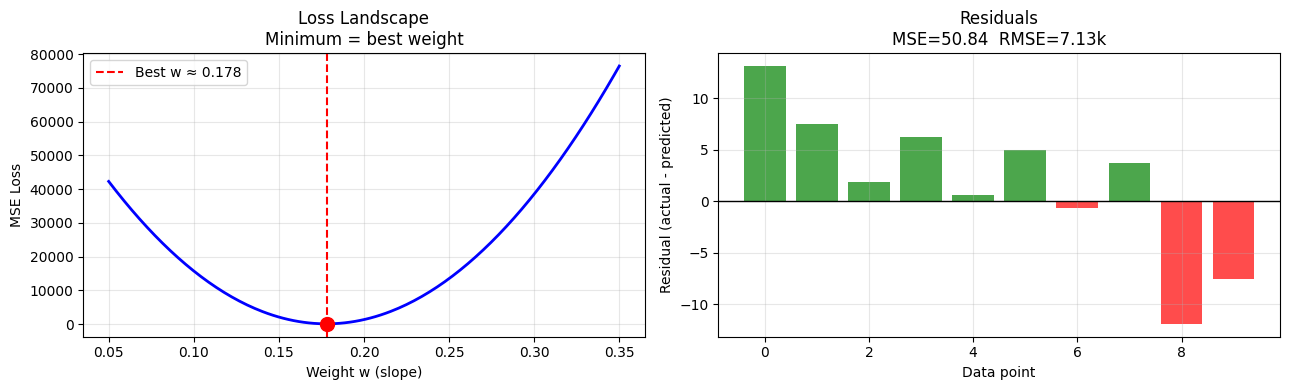

In [3]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

# Compare different lines by their MSE
candidates = [
    (0.10, 100, 'Terrible (flat)'),
    (0.15,  60, 'Bad'),
    (0.19,  35, 'Our manual guess'),
    (0.20,  20, 'Slightly different'),
]

print("=== MSE for Different Lines ===")
for w_try, b_try, label in candidates:
    preds = w_try * sizes + b_try
    loss  = mse(prices, preds)
    rmse_ = rmse(prices, preds)
    print(f"  {label:25}  w={w_try}  b={b_try:3d}  MSE={loss:6.2f}  RMSE={rmse_:.2f}k")

# Visualize the loss landscape
w_vals = np.linspace(0.05, 0.35, 200)
losses = [mse(prices, w_try * sizes + 30) for w_try in w_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(w_vals, losses, 'b-', lw=2)
best_w = w_vals[np.argmin(losses)]
axes[0].axvline(best_w, color='red', linestyle='--', label=f'Best w ≈ {best_w:.3f}')
axes[0].scatter([best_w], [min(losses)], color='red', s=100, zorder=5)
axes[0].set_xlabel('Weight w (slope)')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Landscape\nMinimum = best weight')
axes[0].legend()

# Error visualization
preds_best = best_w * sizes + 30
errors = prices - preds_best
axes[1].bar(range(len(sizes)), errors, color=['red' if e < 0 else 'green' for e in errors], alpha=0.7)
axes[1].axhline(0, color='k', lw=1)
axes[1].set_xlabel('Data point')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title(f'Residuals\nMSE={mse(prices, preds_best):.2f}  RMSE={rmse(prices, preds_best):.2f}k')

plt.tight_layout()
plt.show()

---
## 4. Ordinary Least Squares (OLS) — The Closed-Form Solution

For linear regression, we can solve for the **exact optimal weights** with one formula — no iteration needed.

${\sum (y - \hat{y})^2}$

**Why squared?**
-	Prevents negative cancellation
-	Penalizes large errors more
-	Smooth & differentiable

Closed-form solution:

${\mathbf{w} = (X^T X)^{-1} X^T \mathbf{y}}$

**Plain English:** This is just algebra — rearranging the MSE minimization to solve for w directly.

**When to use OLS:**
- Dataset fits in memory
- Number of features < ~10,000
- We want an exact answer instantly

**When NOT to use OLS:**
- Dataset is huge (matrix inversion is O(n³))
- Too many features (matrix becomes singular)
- Use gradient descent instead (Section 5)

=== OLS Exact Solution ===
Weight (w): 0.168182  → each sqft adds $168.18 to price
Bias   (b): 46.727273  → base price $46.7k
MSE: 14.9091k
RMSE: 3.8612k

Prediction for 1500 sqft house: $299.0k


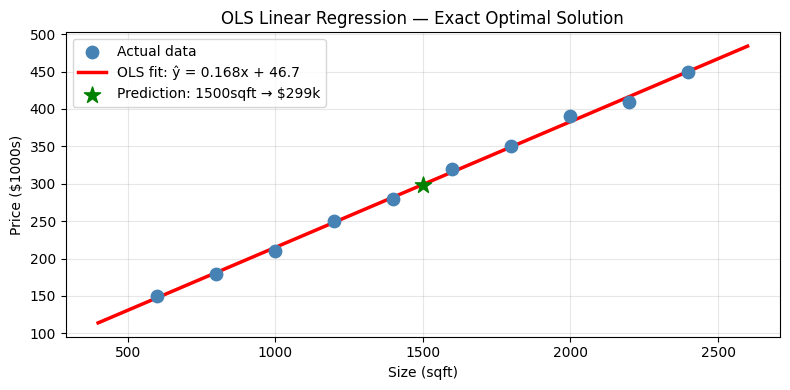

In [4]:
# OLS from scratch — solve for w exactly
def ols_fit(X, y):
    # Add bias column (column of 1s)
    X_b = np.column_stack([np.ones(len(X)), X])
    # Normal equation: w = (XᵀX)⁻¹ Xᵀy
    w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    return w[0], w[1:]   # bias, weights

X = sizes.reshape(-1, 1).astype(float)
b_ols, w_ols = ols_fit(X, prices.astype(float))

print("=== OLS Exact Solution ===")
print(f"Weight (w): {w_ols[0]:.6f}  → each sqft adds ${w_ols[0]*1000:.2f} to price")
print(f"Bias   (b): {b_ols:.6f}  → base price ${b_ols:.1f}k")

preds_ols = w_ols[0] * sizes + b_ols
print(f"MSE: {mse(prices, preds_ols):.4f}k")
print(f"RMSE: {rmse(prices, preds_ols):.4f}k")

# Predict a new house
new_size = 1500
prediction = w_ols[0] * new_size + b_ols
print(f"\nPrediction for {new_size} sqft house: ${prediction:.1f}k")

# Visualize OLS fit
fig, ax = plt.subplots(figsize=(8, 4))
x_range = np.linspace(400, 2600, 100)
ax.scatter(sizes, prices, color='steelblue', s=80, zorder=5, label='Actual data')
ax.plot(x_range, w_ols[0]*x_range + b_ols, 'r-', lw=2.5,
        label=f'OLS fit: ŷ = {w_ols[0]:.3f}x + {b_ols:.1f}')
ax.scatter([new_size], [prediction], color='green', s=150, zorder=6, marker='*',
          label=f'Prediction: {new_size}sqft → ${prediction:.0f}k')
ax.set_xlabel('Size (sqft)')
ax.set_ylabel('Price ($1000s)')
ax.set_title('OLS Linear Regression — Exact Optimal Solution')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Gradient Descent — Learning Iteratively

OLS finds the exact answer in one step — but what about neural networks with millions of parameters?
We can't invert a million × million matrix. Instead, we **walk downhill** on the loss surface.

### The Algorithm:
```
1. Start with random weights
2. Compute predictions with current weights
3. Compute the loss (MSE)
4. Compute gradients (which direction is "downhill"?)
5. Take a small step in that direction
6. Repeat until convergence
```

### The Update Rule:
$${w \leftarrow w - \eta \cdot \frac{\partial \text{MSE}}{\partial w}}$$

The gradient of MSE with respect to w:
$${\frac{\partial \text{MSE}}{\partial w} = \frac{-2}{n} \sum_i x_i(y_i - \hat{y}_i)}$$

**η (eta) = learning rate** — how big a step to take each iteration.

In [ ]:
def gradient_descent_lr(X, y, lr=0.000001, epochs=2000):
    n = len(X)
    w, b = 0.0, 0.0  # start at zero
    losses = []

    for epoch in range(epochs):
        y_pred = w * X + b

        # Gradients
        dw = (-2/n) * np.sum(X * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)

        # Update
        w -= lr * dw
        b -= lr * db

        losses.append(mse(y, y_pred))

    return w, b, losses

X_f = sizes.astype(float)
y_f = prices.astype(float)

w_gd, b_gd, losses = gradient_descent_lr(X_f, y_f, lr=0.000001, epochs=3000)

print("=== Gradient Descent Result ===")
print(f"Weight: {w_gd:.6f}  (OLS was: {w_ols[0]:.6f})")
print(f"Bias:   {b_gd:.6f}  (OLS was: {b_ols:.6f})")
print(f"Final MSE: {losses[-1]:.4f}")
print("Both methods converge to the same answer ✓")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(losses, 'b-', lw=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Curve During Training\\nLoss decreases as weights improve')

# Show weight path on loss landscape
w_vals  = np.linspace(-0.1, 0.4, 200)
b_fixed = b_gd
loss_landscape = [mse(y_f, wv*X_f + b_fixed) for wv in w_vals]
axes[1].plot(w_vals, loss_landscape, 'b-', lw=2)

# Show first few gradient steps
w_trace, b_trace = 0.0, 0.0
for step in range(25):
    y_p = w_trace * X_f + b_trace
    dw  = (-2/len(X_f)) * np.sum(X_f * (y_f - y_p))
    db  = (-2/len(X_f)) * np.sum(y_f - y_p)
    w_new = w_trace - 0.000001 * dw
    axes[1].annotate('', xy=(w_new, mse(y_f, w_new*X_f+b_trace)),
                    xytext=(w_trace, mse(y_f, w_trace*X_f+b_trace)),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    w_trace = w_new
    b_trace -= 0.000001 * db

axes[1].scatter([w_gd], [losses[-1]], color='green', s=100, zorder=5, label='Converged')
axes[1].set_xlabel('Weight w')
axes[1].set_ylabel('Loss')
axes[1].set_title('Gradient Descent Steps\\nWalking downhill on the loss surface')
axes[1].legend()

plt.tight_layout()
plt.show()

NameError: name 'sizes' is not defined

---
## 6. Multiple Features — Real Datasets Have Many Inputs

Real houses aren't priced on size alone. They have:
- Number of bedrooms
- Number of bathrooms
- Age of the house
- Neighborhood quality
- Distance to schools
- ...and dozens more

Multiple linear regression handles all of this:

$${\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + ... + w_n x_n + b}$$

**In matrix form** (all samples at once):
$${\hat{\mathbf{y}} = X \mathbf{w} + b}$$

Where X is shape `(n_samples, n_features)` — this is just one big matrix multiplication.

=== Multiple Linear Regression ===
Intercept (b): 46.89

Learned weights vs True weights:
  Size(sqft)  : learned=+0.149  true=+0.150
  Bedrooms    : learned=+14.602  true=+15.000
  Age(yrs)    : learned=-1.435  true=-1.500
  Quality     : learned=+8.337  true=+8.000
\nRMSE: 20.82k
R²:   0.9042


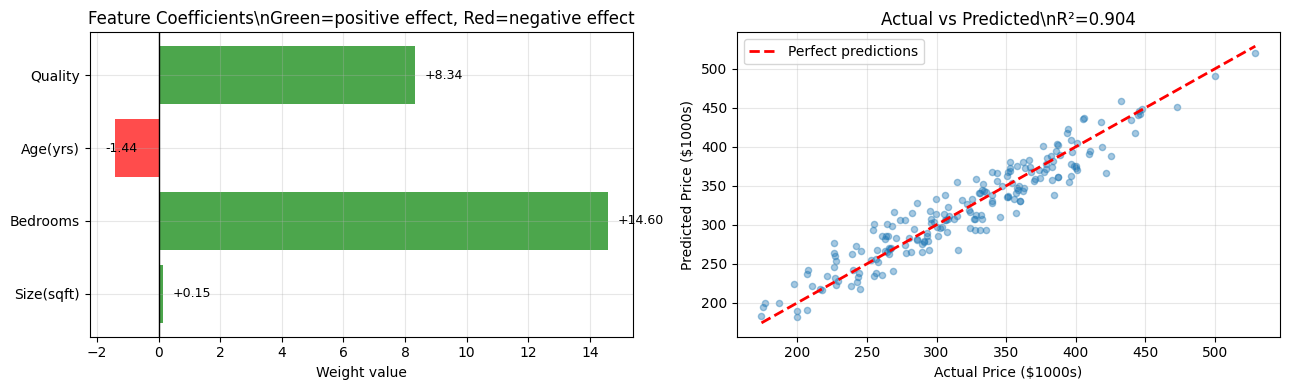

In [ ]:
# Multi-feature dataset
np.random.seed(42)
n = 200

# Generate synthetic house data
size     = np.random.normal(1500, 400, n)        # sqft
bedrooms = np.random.randint(1, 6, n).astype(float)
age      = np.random.uniform(1, 50, n)            # years old
quality  = np.random.uniform(1, 10, n)            # neighborhood score

# True relationship (we know this because we created it)
price = (0.15 * size
        + 15 * bedrooms
        - 1.5 * age
        + 8 * quality
        + np.random.normal(0, 20, n)
        + 50)

X_multi = np.column_stack([size, bedrooms, age, quality])
feature_names = ['Size(sqft)', 'Bedrooms', 'Age(yrs)', 'Quality']

# Fit with sklearn
model_multi = LinearRegression()
model_multi.fit(X_multi, price)

print("=== Multiple Linear Regression ===")
print(f"Intercept (b): {model_multi.intercept_:.2f}")
print()
print("Learned weights vs True weights:")
true_weights = [0.15, 15, -1.5, 8]
for fname, learned_w, true_w in zip(feature_names, model_multi.coef_, true_weights):
    print(f"  {fname:12}: learned={learned_w:+.3f}  true={true_w:+.3f}")

preds_multi = model_multi.predict(X_multi)
print(f"\\nRMSE: {rmse(price, preds_multi):.2f}k")
print(f"R²:   {r2_score(price, preds_multi):.4f}")

# Feature importance via coefficient magnitude
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['green' if c > 0 else 'red' for c in model_multi.coef_]
axes[0].barh(feature_names, model_multi.coef_, color=colors, alpha=0.7)
axes[0].axvline(0, color='k', lw=1)
axes[0].set_title('Feature Coefficients\\nGreen=positive effect, Red=negative effect')
axes[0].set_xlabel('Weight value')
for i, v in enumerate(model_multi.coef_):
    axes[0].text(v + (0.3 if v > 0 else -0.3), i, f'{v:+.2f}', va='center', fontsize=9)

axes[1].scatter(price, preds_multi, alpha=0.4, s=20)
lims = [min(price.min(), preds_multi.min()), max(price.max(), preds_multi.max())]
axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect predictions')
axes[1].set_xlabel('Actual Price ($1000s)')
axes[1].set_ylabel('Predicted Price ($1000s)')
axes[1].set_title(f'Actual vs Predicted\\nR²={r2_score(price, preds_multi):.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

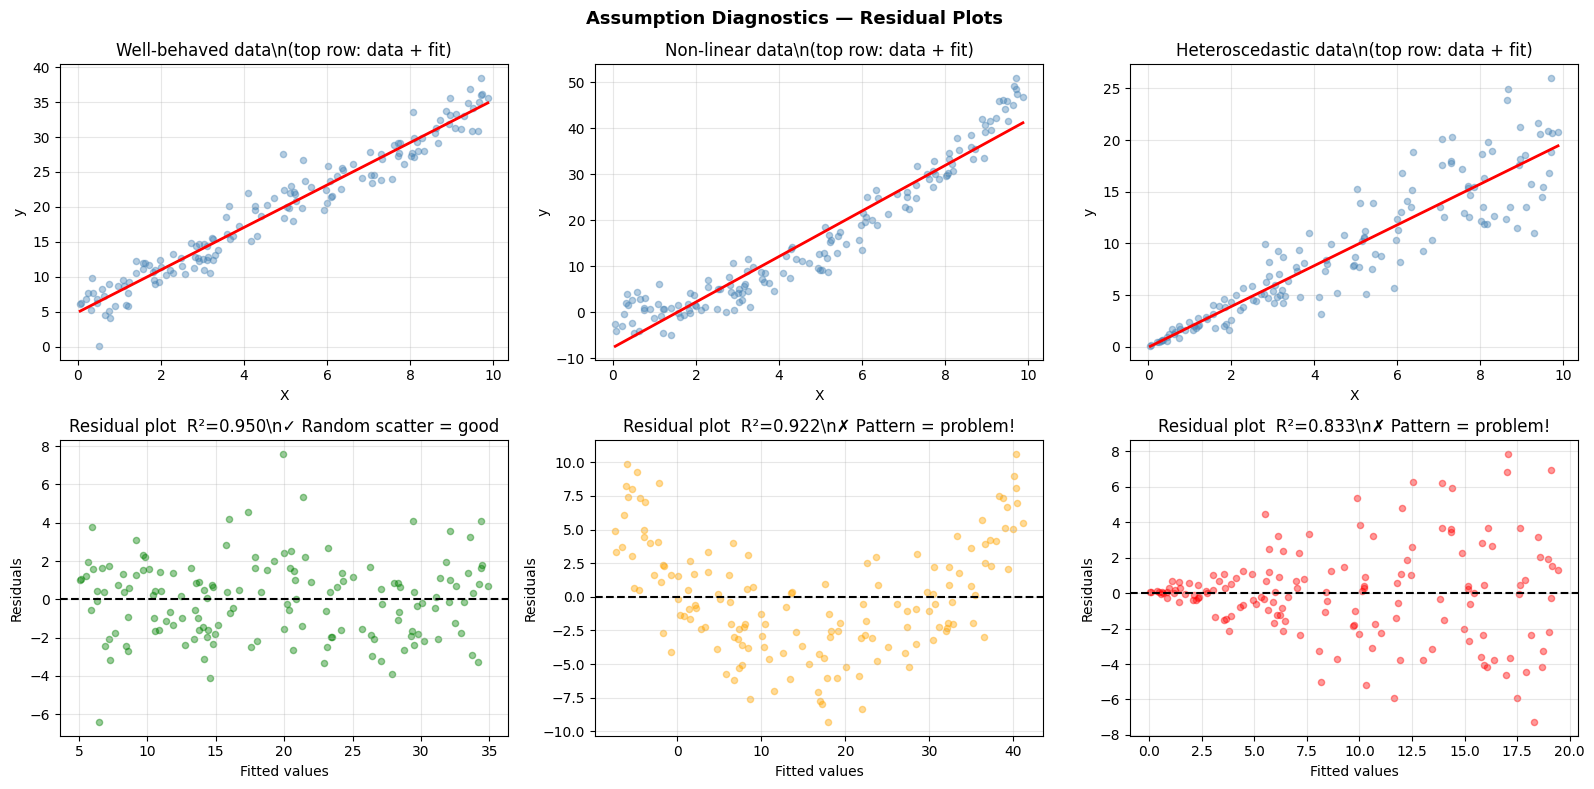

How to read residual plots:
  ✓ Random scatter around zero  → assumptions met
  ✗ Curved pattern              → non-linear relationship (use polynomial regression)
  ✗ Fan shape (widening)        → heteroscedasticity (try log transform of y)


In [ ]:
# Diagnose linear regression assumptions visually
np.random.seed(42)
n = 150

# A well-behaved dataset
X_good = np.random.uniform(0, 10, n)
y_good = 3 * X_good + 5 + np.random.normal(0, 2, n)

# A dataset that violates linearity
y_nonlinear = 0.5 * X_good**2 + np.random.normal(0, 3, n)

# A dataset with heteroscedasticity (variance grows with x)
y_hetero = 2 * X_good + np.random.normal(0, 0.5 * X_good, n)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, (y_data, label, color) in enumerate([
    (y_good, 'Well-behaved data', 'green'),
    (y_nonlinear, 'Non-linear data', 'orange'),
    (y_hetero, 'Heteroscedastic data', 'red'),
]):
    # Fit linear model
    m = LinearRegression().fit(X_good.reshape(-1,1), y_data)
    preds = m.predict(X_good.reshape(-1,1))
    resids = y_data - preds

    # Scatter + fit line
    axes[0, col].scatter(X_good, y_data, alpha=0.4, s=20, color='steelblue')
    axes[0, col].plot(np.sort(X_good), m.predict(np.sort(X_good).reshape(-1,1)),
                      'r-', lw=2)
    axes[0, col].set_title(f'{label}\\n(top row: data + fit)')
    axes[0, col].set_xlabel('X')
    axes[0, col].set_ylabel('y')

    # Residual plot
    axes[1, col].scatter(preds, resids, alpha=0.4, s=20, color=color)
    axes[1, col].axhline(0, color='k', lw=1.5, linestyle='--')
    axes[1, col].set_xlabel('Fitted values')
    axes[1, col].set_ylabel('Residuals')
    r2 = r2_score(y_data, preds)
    axes[1, col].set_title(f'Residual plot  R²={r2:.3f}\\n'
                          f'{"✓ Random scatter = good" if col==0 else "✗ Pattern = problem!"}')

plt.suptitle('Assumption Diagnostics — Residual Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("How to read residual plots:")
print("  ✓ Random scatter around zero  → assumptions met")
print("  ✗ Curved pattern              → non-linear relationship (use polynomial regression)")
print("  ✗ Fan shape (widening)        → heteroscedasticity (try log transform of y)")

---
## 8. Evaluating the Model

Once trained, how do we know if our model is good?

| Metric | Formula | Meaning |
|---|---|---|
| **R²** | `1 - SS_res/SS_tot` | % of variance explained (1.0 = perfect) |
| **RMSE** | `√mean((y-ŷ)²)` | Average error in same units as y |
| **MAE** | `mean(|y-ŷ|)` | Average absolute error (robust to outliers) |

**The most important rule:** Always evaluate on **held-out test data** — data the model has never seen.  
A model that memorizes training data is useless in production.

=== Model Evaluation ===
Train size: 240  Test size: 60

Train:  R²=0.9729  RMSE=1.9080  MAE=1.5151
Test :  R²=0.9750  RMSE=1.8587  MAE=1.4633

Gap = -0.0021 → Very small, model generalizes well ✓


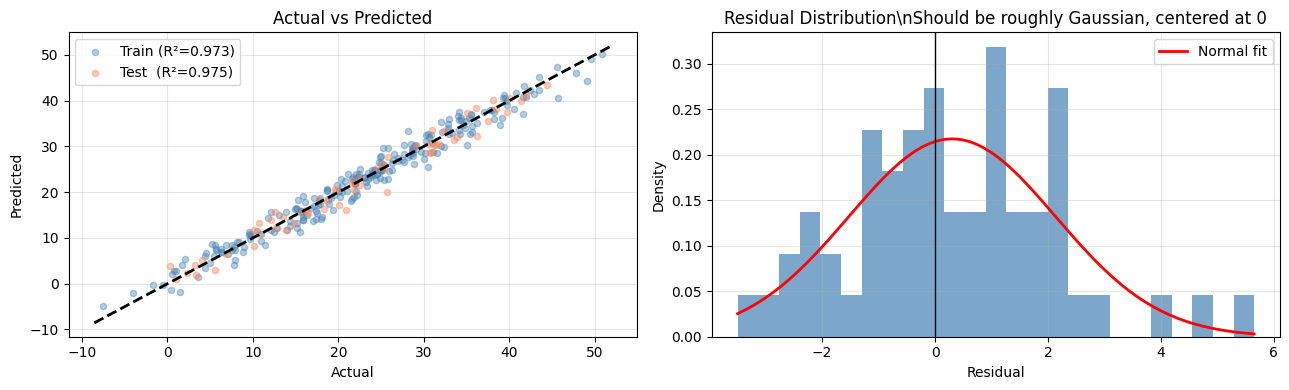

In [ ]:
from scipy.stats import norm

# Proper evaluation: train/test split
np.random.seed(0)
n = 300
X_eval = np.random.uniform(0, 10, (n, 3))
y_eval = 2*X_eval[:,0] - 1.5*X_eval[:,1] + 3*X_eval[:,2] + 5 + np.random.normal(0, 2, n)

X_train, X_test, y_train, y_test = train_test_split(X_eval, y_eval, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# Metrics
def eval_metrics(y_true, y_pred, name):
    r2   = r2_score(y_true, y_pred)
    rmse_ = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    print(f"{name}:  R²={r2:.4f}  RMSE={rmse_:.4f}  MAE={mae:.4f}")
    return r2, rmse_, mae

print("=== Model Evaluation ===")
print(f"Train size: {len(X_train)}  Test size: {len(X_test)}")
print()
r2_tr,_,_ = eval_metrics(y_train, y_pred_train, "Train")
r2_te,_,_ = eval_metrics(y_test,  y_pred_test,  "Test ")
print()
gap = r2_tr - r2_te
if gap < 0.02:
    print(f"Gap = {gap:.4f} → Very small, model generalizes well ✓")
elif gap < 0.1:
    print(f"Gap = {gap:.4f} → Small, acceptable")
else:
    print(f"Gap = {gap:.4f} → Large, model may be overfitting")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Actual vs Predicted
for y_true, y_pred, color, label in [
    (y_train, y_pred_train, 'steelblue', f'Train (R²={r2_tr:.3f})'),
    (y_test,  y_pred_test,  'coral',     f'Test  (R²={r2_te:.3f})'),
]:
    axes[0].scatter(y_true, y_pred, alpha=0.4, s=20, color=color, label=label)
lim = [y_eval.min()-1, y_eval.max()+1]
axes[0].plot(lim, lim, 'k--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residuals distribution
resids_test = y_test - y_pred_test
axes[1].hist(resids_test, bins=25, color='steelblue', alpha=0.7, density=True)

x_norm = np.linspace(resids_test.min(), resids_test.max(), 100)
axes[1].plot(x_norm, norm.pdf(x_norm, resids_test.mean(), resids_test.std()),
            'r-', lw=2, label='Normal fit')
axes[1].axvline(0, color='k', lw=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Density')
axes[1].set_title('Residual Distribution\\nShould be roughly Gaussian, centered at 0')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 9. Sklearn in 5 Lines

In practice, We never implement linear regression from scratch.
Here's the full workflow in sklearn:

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np

# 1. Prepare data (X = features, y = target)
np.random.seed(0)
X = np.random.randn(200, 3)
y = 2*X[:,0] - 1.5*X[:,1] + 3*X[:,2] + np.random.randn(200)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

# 5. Evaluate
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Coefficients: {model.coef_.round(3)}")
print(f"Intercept: {model.intercept_:.4f}")
print()
print("That's it. 5 lines (split, train, predict, evaluate).")
print("Everything before this section was building intuition for what happens inside.")

R²:   0.9241
RMSE: 1.0162
Coefficients: [ 2.081 -1.684  2.832]
Intercept: -0.1658

That's it. 5 lines (split, train, predict, evaluate).
Everything before this section was building intuition for what happens inside.


---
## 10. Real Example — California Housing

Now let's apply everything to a realistic dataset.

**Dataset:** California Housing — predict median house value
(This is similar to the famous Boston Housing dataset used on Sklearn)

**Features:**
- `MedInc` — median income
- `HouseAge` — median house age
- `AveRooms` — average rooms per house
- `AveBedrms` — average bedrooms
- `Population` — block population
- `AveOccup` — average household size
- `Latitude`, `Longitude` — location

**Target:** Median house value (in $100,000s)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('../../../datasets/california_housing.csv',)

print("=== California Housing Dataset ===")
print(f"Shape: {df.shape}  ({df.shape[0]} houses, {df.shape[1]-1} features + target)")
print()
print(df.describe().round(3))

=== California Housing Dataset ===
Shape: (20640, 9)  (20640 houses, 8 features + target)

          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.097    1425.477      3.071   
std        1.900     12.586      2.474      0.474    1132.462     10.386   
min        0.500      1.000      0.846      0.333       3.000      0.692   
25%        2.563     18.000      4.441      1.006     787.000      2.430   
50%        3.535     29.000      5.229      1.049    1166.000      2.818   
75%        4.743     37.000      6.052      1.100    1725.000      3.282   
max       15.000     52.000    141.909     34.067   35682.000   1243.333   

        Latitude  Longitude  MedHouseVal  
count  20640.000  20640.000    20640.000  
mean      35.632   -119.570        2.069  
std        2.136      2.004        1.154  
min       32.540   -124.350        0.150  
25%      

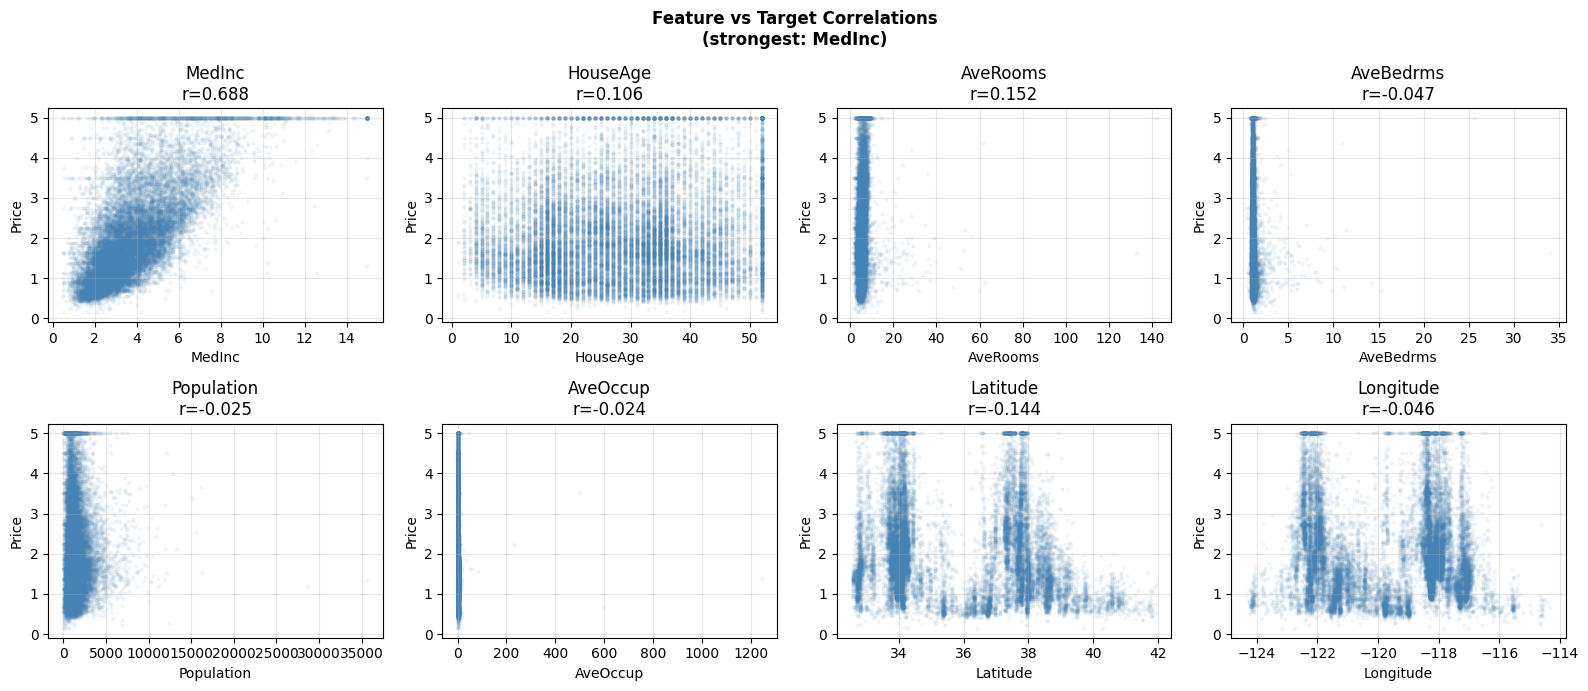

In [ ]:
import numpy as np

# Step 1: Explore the data
_, axes = plt.subplots(2, 4, figsize=(16, 7))

feature_names = df.columns.drop("MedHouseVal")

for axis, f_name in zip(axes.flat, feature_names):
    axis.scatter(df[f_name], df['MedHouseVal'], alpha=0.05, s=5, color='steelblue')
    axis.set_xlabel(f_name)
    axis.set_ylabel('Price')
    # Correlation
    r = np.corrcoef(df[f_name], df['MedHouseVal'])[0,1]
    axis.set_title(f'{f_name}\nr={r:.3f}')

plt.suptitle('Feature vs Target Correlations\n(strongest: MedInc)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Step 2: Prepare and train
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

X_housing = df[feature_names].values
y_housing  = df['MedHouseVal'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)

# Scale features — important! features are on very different scales
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

# Train
model_housing = LinearRegression()
model_housing.fit(X_tr_sc, y_tr)

y_pred_tr = model_housing.predict(X_tr_sc)
y_pred_te = model_housing.predict(X_te_sc)

print("=== Results ===")
print(f"Train R²:  {r2_score(y_tr, y_pred_tr):.4f}")
print(f"Test  R²:  {r2_score(y_te, y_pred_te):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_te, y_pred_te)):.4f}  (×$100k = ${np.sqrt(mean_squared_error(y_te, y_pred_te))*100:.0f}k average error)")
print()

# Cross-validation for a robust score
cv_scores = cross_val_score(LinearRegression(), X_tr_sc, y_tr, cv=5, scoring='r2')
print(f"5-fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print()
print("Feature importance (by coefficient after scaling):")
for fname, coef in sorted(zip(feature_names, model_housing.coef_), key=lambda x: abs(x[1]), reverse=True):
    bar = '█' * int(abs(coef)*10)
    sign = '+' if coef > 0 else '-'
    print(f"  {fname:12} {sign}{abs(coef):.4f}  {bar}")

=== Results ===
Train R²:  0.6126
Test  R²:  0.5758
Test RMSE: 0.7456  (×$100k = $75k average error)

5-fold CV R²: 0.6115 ± 0.0065

Feature importance (by coefficient after scaling):
  Latitude     -0.8969  ████████
  Longitude    -0.8698  ████████
  MedInc       +0.8544  ████████
  AveBedrms    +0.3393  ███
  AveRooms     -0.2944  ██
  HouseAge     +0.1225  █
  AveOccup     -0.0408  
  Population   -0.0023  


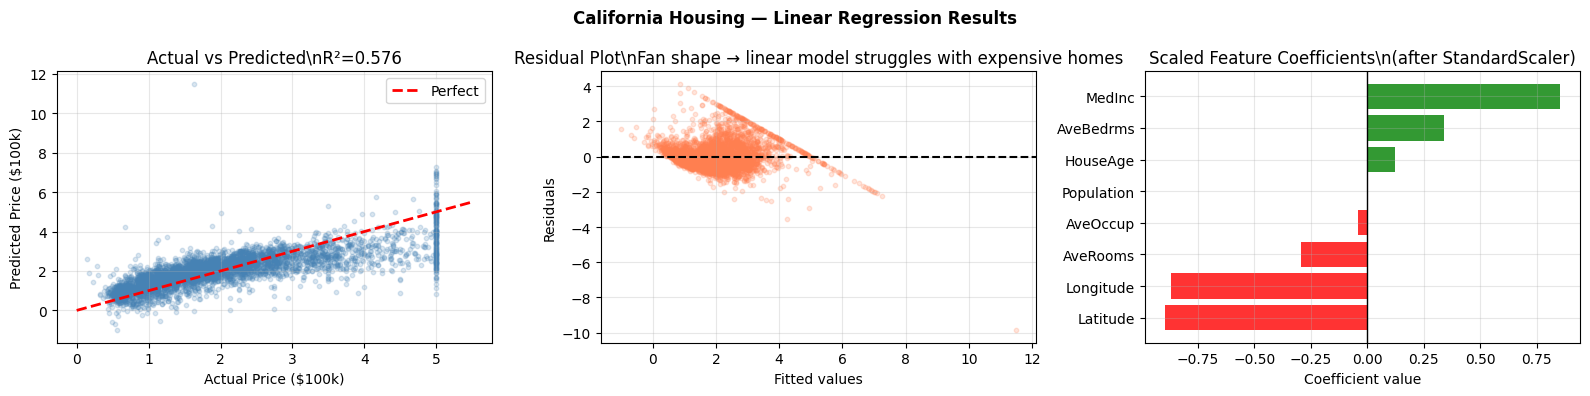


Observations:
  ✓ MedInc (income) is the strongest predictor — makes sense
  ✓ Latitude negative → further north = lower price in CA
  ✗ R²=0.60 — linear regression explains 60% of variance
  ✗ Residual fan shape → some non-linearity the model misses
  → Next step: try polynomial features or regularization to improve


In [ ]:
# Step 3: Visualize results + residuals
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Actual vs Predicted
axes[0].scatter(y_te, y_pred_te, alpha=0.2, s=10, color='steelblue')
lim = [0, 5.5]
axes[0].plot(lim, lim, 'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Actual Price ($100k)')
axes[0].set_ylabel('Predicted Price ($100k)')
axes[0].set_title(f'Actual vs Predicted\\nR²={r2_score(y_te, y_pred_te):.3f}')
axes[0].legend()

# Residuals vs fitted
resids = y_te - y_pred_te
axes[1].scatter(y_pred_te, resids, alpha=0.2, s=10, color='coral')
axes[1].axhline(0, color='k', lw=1.5, linestyle='--')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot\\nFan shape → linear model struggles with expensive homes')

# Feature coefficients
coef_df = sorted(zip(feature_names, model_housing.coef_), key=lambda x: x[1])
names_sorted, coefs_sorted = zip(*coef_df)
colors = ['red' if c < 0 else 'green' for c in coefs_sorted]
axes[2].barh(names_sorted, coefs_sorted, color=colors, alpha=0.8)
axes[2].axvline(0, color='k', lw=1)
axes[2].set_title('Scaled Feature Coefficients\\n(after StandardScaler)')
axes[2].set_xlabel('Coefficient value')

plt.suptitle('California Housing — Linear Regression Results', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("Observations:")
print("  ✓ MedInc (income) is the strongest predictor — makes sense")
print("  ✓ Latitude negative → further north = lower price in CA")
print("  ✗ R²=0.60 — linear regression explains 60% of variance")
print("  ✗ Residual fan shape → some non-linearity the model misses")
print("  → Next step: try polynomial features or regularization to improve")

---
## Summary

```
Linear Regression
  ŷ = wᵀx + b

Training
  OLS:              w = (XᵀX)⁻¹Xᵀy    (exact, fast, requires full memory)
  Gradient descent: w ← w - η·∇MSE     (iterative, scales to huge datasets)

Loss
  MSE  = mean((y - ŷ)²)    (training objective)
  RMSE = √MSE              (interpretable, same units as y)
  R²   = 1 - SS_res/SS_tot (how much variance explained)

sklearn workflow
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
```

### What to learn next
- **polynomial_regression.ipynb** — when the relationship isn't linear
- **regularization.ipynb** — Ridge/Lasso to prevent overfitting
- **decision_trees.ipynb** — non-linear regression without polynomial features